In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
data = pd.read_csv("flight_data_2024_sample.csv")
data.shape

(10000, 35)

In [18]:
print("=" * 5 + " First 5 Data " + 5 * "=")
print(data.head())
print("=" * 5 + " Last 5 Data " + 5 * "=")
print(data.tail())

===== First 5 Data =====
   year  month  day_of_month  day_of_week     fl_date op_unique_carrier  \
0  2024      4            18            4  2024-04-18                MQ   
1  2024      1             1            1  2024-01-01                AA   
2  2024     12            12            4  2024-12-12                9E   
3  2024      4             8            1  2024-04-08                WN   
4  2024      2            16            5  2024-02-16                WN   

   op_carrier_fl_num origin       origin_city_name origin_state_nm  ...  \
0             3535.0    DFW  Dallas/Fort Worth, TX           Texas  ...   
1              148.0    CLT          Charlotte, NC  North Carolina  ...   
2             5440.0    CHA        Chattanooga, TN       Tennessee  ...   
3             1971.0    OMA              Omaha, NE        Nebraska  ...   
4              862.0    BWI          Baltimore, MD        Maryland  ...   

  diverted crs_elapsed_time actual_elapsed_time  air_time  distance  \
0 

In [19]:
# Mising or null values

print("Missing Values in dataset:", data.isnull().sum().sum())

Missing Values in dataset: 11223


In [20]:
# Data quality and data type

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 10000 non-null  int64  
 1   month                10000 non-null  int64  
 2   day_of_month         10000 non-null  int64  
 3   day_of_week          10000 non-null  int64  
 4   fl_date              10000 non-null  object 
 5   op_unique_carrier    10000 non-null  object 
 6   op_carrier_fl_num    10000 non-null  float64
 7   origin               10000 non-null  object 
 8   origin_city_name     10000 non-null  object 
 9   origin_state_nm      10000 non-null  object 
 10  dest                 10000 non-null  object 
 11  dest_city_name       10000 non-null  object 
 12  dest_state_nm        10000 non-null  object 
 13  crs_dep_time         10000 non-null  int64  
 14  dep_time             9884 non-null   float64
 15  dep_delay            9884 non-null   

In [21]:
# Statistical Summarry

data.describe().T

,count,mean,std,min,25%,50%,75%,max
year,10000.0,2024.000000,0.000000,2024.0,2024.00,2024.0,2024.00,2024.0
month,10000.0,6.613200,3.377858,1.0,4.00,7.0,10.00,12.0
day_of_month,10000.0,15.843000,8.792774,1.0,8.00,16.0,23.00,31.0
day_of_week,10000.0,3.950200,2.006370,1.0,2.00,4.0,6.00,7.0
op_carrier_fl_num,10000.0,2529.762600,1655.998442,1.0,1172.00,2254.0,3742.00,8771.0
crs_dep_time,10000.0,1324.447700,488.544631,22.0,905.00,1320.0,1734.25,2359.0
dep_time,9884.0,1330.160664,504.953299,1.0,910.00,1324.0,1745.00,2400.0
dep_delay,9884.0,13.002428,53.614819,-22.0,-6.00,-2.0,9.25,2011.0
taxi_out,9880.0,17.878644,9.773379,4.0,12.00,15.0,21.00,154.0
wheels_off,9880.0,1353.564879,507.452551,1.0,928.75,1337.0,1759.00,2400.0


In [22]:
# Constant Features

const_features = []

for col in data.columns:

    if data[col].nunique() <= 1:

        const_features.append(col)

print(f"Constant Features: {const_features}")


Constant Features: ['year']


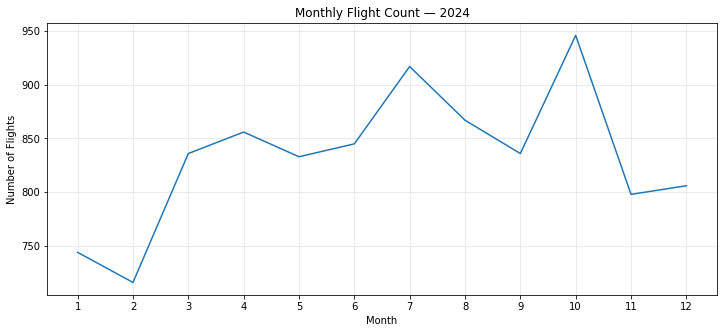

In [36]:
# Visualization of features using pyplot

monthly_flights = data.groupby("month").size().reset_index(name="flight_count")
# print(monthly_flights)

x = monthly_flights["month"]
y = monthly_flights["flight_count"]

plt.figure(figsize=(12, 5))

plt.plot(x, y)

plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.title("Monthly Flight Count — 2024")

plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)

plt.show()

## Inspection Summary

### Missing or null values
- The dataset contains 11,223 missing cells, primarily in operational and timing columns.

### Data quality and consistency
- `year` is constant at 2024 and provides no useful variation.
- Cancellation, diversion, delay, and timing fields should be checked for logical consistency.

### Data types and structure
- The dataset contains 10,000 rows and 35 columns, with integer, float, and object data types.

### Other issues identified
- Missing values should be handled according to their operational meaning rather than replaced uniformly.

